# 資料分析

1. 資料讀取
- 載入 `data/df_clean.csv`
- 確認欄位與資料筆數

2. 探索性分析（EDA）

    2.1 基本統計
    - 計算 `Duration (minutes)` 的 mean、median、std、min、max
    - 輸出統計表格

    2.2 各災害種類的 Duration 統計
    - 以 `Cause` 為分組依據
    - 計算各類別的 mean、median、std、min、max
    - 輸出統計表格

    2.3 Cause 分布統計
    - 計算各 Cause 類別的筆數與佔比
    - 繪製圓餅圖

    2.4 Duration 直方圖
    - 以線性尺度繪製 Duration 直方圖，觀察主體分布
    - 以 log 尺度繪製 Duration 直方圖，觀察尾部行為

3. CCDF 計算與繪製
- 計算經驗 CCDF：對 Duration 排序後計算 P(X > x)
- 以 log-log 尺度繪製 CCDF
- 此圖為後續擬合比較的基準圖

4. Log-normal 分布擬合

    4.1 估計 μ、σ

    4.2 CCDF 比較圖
    - 在 3. 的 CCDF 圖上疊加 log-normal 擬合曲線
    - 視覺觀察擬合曲線與實際資料的偏離位置，初步判斷尾部開始不符合的區間

5. Log-normal 有效範圍搜尋

    5.1 Binary search + KS test (檢測資料是否符合某個分布的方法)
    - 搜尋範圍：`[log(duration 最小值), log(duration 最大值)]`（log 空間）
    - 每次取中點 `mid`，對 `duration ≤ exp(mid)` 的資料進行 KS test
        - p > 0.10 → 符合 log-normal，往右搜尋（`low = mid`）
        - p ≤ 0.10 → 不符合，往左搜尋（`high = mid`）
    - 收斂條件：`high - low < 1e-3`（log 空間容忍值）
    - 確保每次 KS test 的樣本數 ≥ 30


    5.2 截斷點結果 (後續改為說明與討論，本檢測方式我認為不適用於這個 case )

6. 相對誤差檢核

7. 結論與策略


# 1. 資料讀取

In [1]:
import pandas as pd
import os

DATA_DIR = "data"

# 載入清理後的資料
df = pd.read_csv(os.path.join(DATA_DIR, "df_clean.csv"))

# 確認欄位與資料筆數
print(f"資料筆數：{len(df)}")
print(f"欄位：{df.columns.tolist()}")
df.head()

資料筆數：9511
欄位：['Name', 'Out Datetime', 'In Datetime', 'Voltage (kV)', 'Duration (minutes)', 'Outage Type', 'Cause', 'year']


,Name,Out Datetime,In Datetime,Voltage (kV),Duration (minutes),Outage Type,Cause,year
0,Napavine-Chehalis Power No 2 500kV line,01/05/2012 16:21,01/05/2012 20:49,500.0,268,Auto,Other,2012
1,Napavine-Chehalis Power No 3 500kV line,01/05/2012 16:21,01/05/2012 20:49,500.0,268,Auto,Other,2012
2,Napavine-Chehalis Power No 1 500kV line,01/05/2012 16:21,01/08/2012 19:33,500.0,4512,Auto,Other,2012
3,Big Eddy-Celilo No 1 500kV line,01/06/2012 17:39,01/06/2012 19:16,500.0,97,Auto,Other,2012
4,Big Eddy-Celilo No 3 230kV line,01/06/2012 17:39,01/13/2012 16:21,230.0,10002,Auto,Other,2012


# 2. 探索性分析（EDA）

## 2.1 基本統計資料

* 紀錄停電時間的 "平均值", "中位數", "標準差", "最小值", "最大值" 等資訊

* 可以看到中位數遠小於平均值的重尾現象，也就是具有極端事件影響導致平均復電時間較長

In [2]:
# 2.1 基本統計
stats = df["Duration (minutes)"].agg(["mean", "median", "std", "min", "max"])
stats.index = ["Mean", "Median", "Std", "Min", "Max"]
stats.to_frame("Duration (minutes)").round(2)

,Duration (minutes)
Mean,988.96
Median,69.00
Std,11381.06
Min,1.00
Max,613412.00


## 2.2 損害原因與復電時間統計資料

In [3]:
# 各災害種類的 Duration 統計
cause_stats = df.groupby("Cause")["Duration (minutes)"].agg(["count", "mean", "median", "std", "min", "max"])
cause_stats.columns = ["Count", "Mean", "Median", "Std", "Min", "Max"]
cause_stats.round(2)

,Count,Mean,Median,Std,Min,Max
Cause,,,,,,
Foreign Trouble,364,443.62,113.0,978.72,1,6835
Lightning,973,271.86,9.0,1038.62,1,10737
Other,3182,1182.87,48.0,13381.11,1,477120
Tree Blown,1301,1636.27,197.0,12439.60,1,273689
Unknown,1605,430.62,47.0,2401.14,1,50196
Weather,1539,1312.98,61.0,16969.46,1,613412
Wind,547,686.55,94.0,3192.17,1,34931


## 2.3 損害原因比例

* 可以看到 weather 的比例很高，但由於資料沒有明確說明 weather 是哪一類的氣候種類，推測高機率為閃電或是風造成的，這可能是人為的登記問題，總不可能有一堆的火災或是砂塵暴吧!

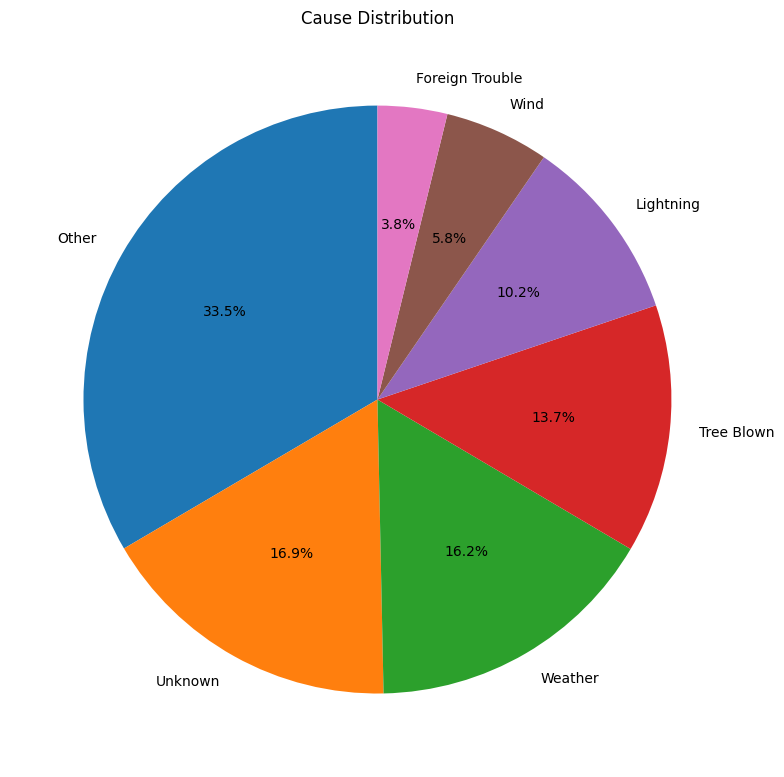

In [4]:
import matplotlib.pyplot as plt

cause_counts = df["Cause"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(cause_counts, labels=cause_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Cause Distribution")
plt.tight_layout()
plt.show()

由於 wheather 的比例比我想像中高、確認一下是否有異常事件在某個年度發生

看起來並沒有大型的天氣災害事件

In [5]:
# 各年度 Cause 分布
year_cause = df.groupby(["year", "Cause"]).size().unstack(fill_value=0)
year_cause_pct = year_cause.div(year_cause.sum(axis=1), axis=0).round(3) * 100
year_cause_pct

Cause,Foreign Trouble,Lightning,Other,Tree Blown,Unknown,Weather,Wind
year,,,,,,,
2012,2.8,9.8,49.1,10.2,13.8,12.2,2.1
2013,4.0,15.7,56.0,1.2,10.5,6.8,5.8
2014,1.8,14.1,29.0,9.6,22.9,17.5,5.3
2015,3.9,5.7,25.3,14.5,17.3,17.9,15.4
2016,6.8,2.1,43.3,12.6,19.3,15.0,1.0
2017,1.9,10.7,29.1,6.8,27.6,15.9,8.0
2018,4.6,9.6,36.4,13.2,14.5,16.5,5.2
2019,5.5,14.9,26.7,24.3,8.8,16.8,3.0
2020,4.3,8.1,22.0,23.8,15.1,21.6,5.0


## 2.4 Duration 直方圖

1. 線性直方圖

2. Log 尺度下直方圖

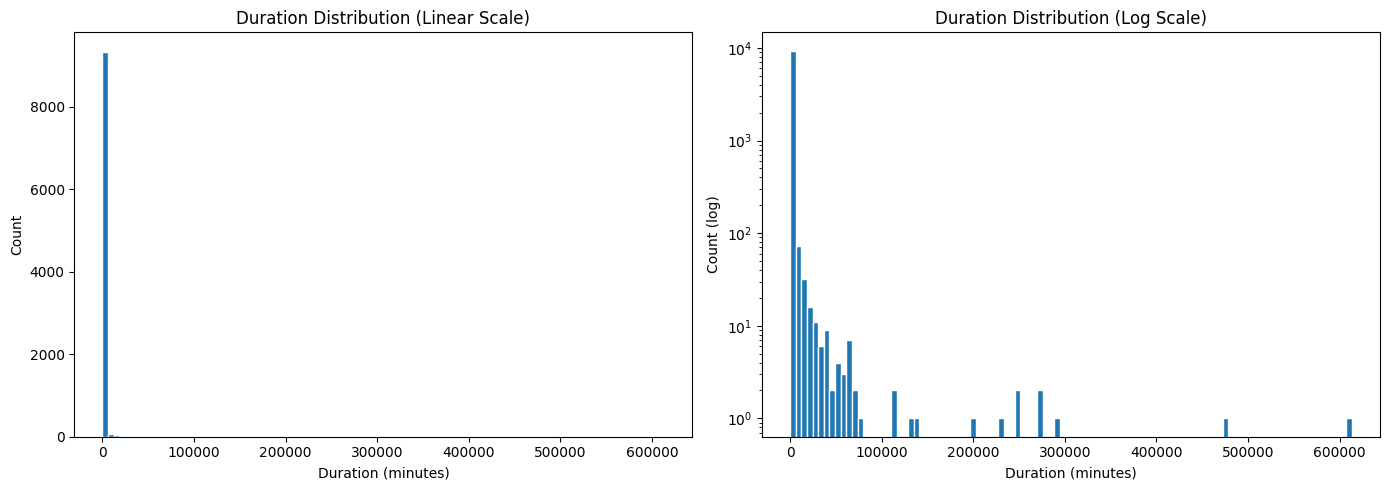

In [6]:
# 2.4 Duration 直方圖
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 線性尺度
axes[0].hist(df["Duration (minutes)"], bins=100, edgecolor="white")
axes[0].set_title("Duration Distribution (Linear Scale)")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Count")

# Log 尺度
axes[1].hist(df["Duration (minutes)"], bins=100, edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("Duration Distribution (Log Scale)")
axes[1].set_xlabel("Duration (minutes)")
axes[1].set_ylabel("Count (log)")

plt.tight_layout()
plt.show()

# 3. CCDF 計算與繪製

* 目的 : 計算並繪製修復時間的經驗互補累積分布函數（CCDF），以 log-log 尺度呈現。若分布具有重尾特性，資料點在 log-log 圖上會呈現近似線性的行為。此圖將作為後續 log-normal 擬合比較的基準。

* 橫軸 : 修復時間（分鐘），以 log 尺度呈現，範圍從 1 分鐘到數萬分鐘，跨越多個數量級。

* 縱軸 : P(X > x) 互補累積機率，即修復時間超過 x 分鐘的機率，以 log 尺度呈現。數值越小代表該修復時間越罕見。

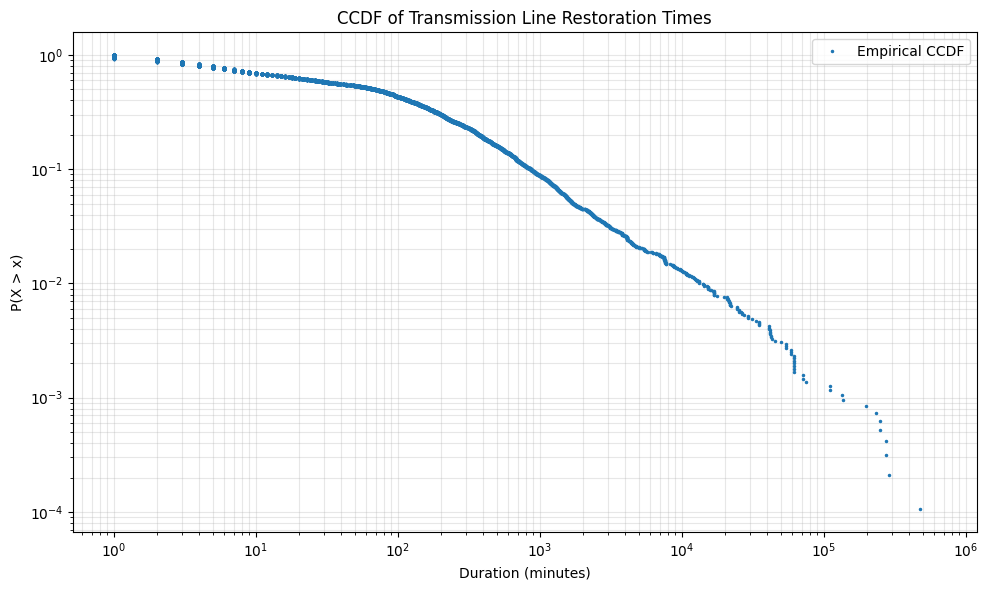

In [7]:
import numpy as np

# 依據修復時間做排序
duration_sorted = np.sort(df["Duration (minutes)"].values)

# 發生該修復時間的互補累積機率 (1-累積機率)
# 使用 arange 將 numpy 陣列做 [1,2...] 排列，也就是記數
ccdf = 1 - np.arange(1, len(duration_sorted) + 1) / len(duration_sorted)

plt.figure(figsize=(10, 6))
plt.loglog(duration_sorted, ccdf, marker=".", linestyle="none", markersize=3, label="Empirical CCDF")
plt.xlabel("Duration (minutes)")
# 修復時間超過 x 分鐘的機率
plt.ylabel("P(X > x)")
plt.title("CCDF of Transmission Line Restoration Times")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Log-normal 分布擬合

## 4.1 計算平均值與標準差

In [8]:
log_duration = np.log(df["Duration (minutes)"])

mu = log_duration.mean()
sigma = log_duration.std()

print(f"μ = {mu:.4f}")
print(f"σ = {sigma:.4f}")

μ = 3.9055
σ = 2.3452


## 4.2 擬合狀況圖

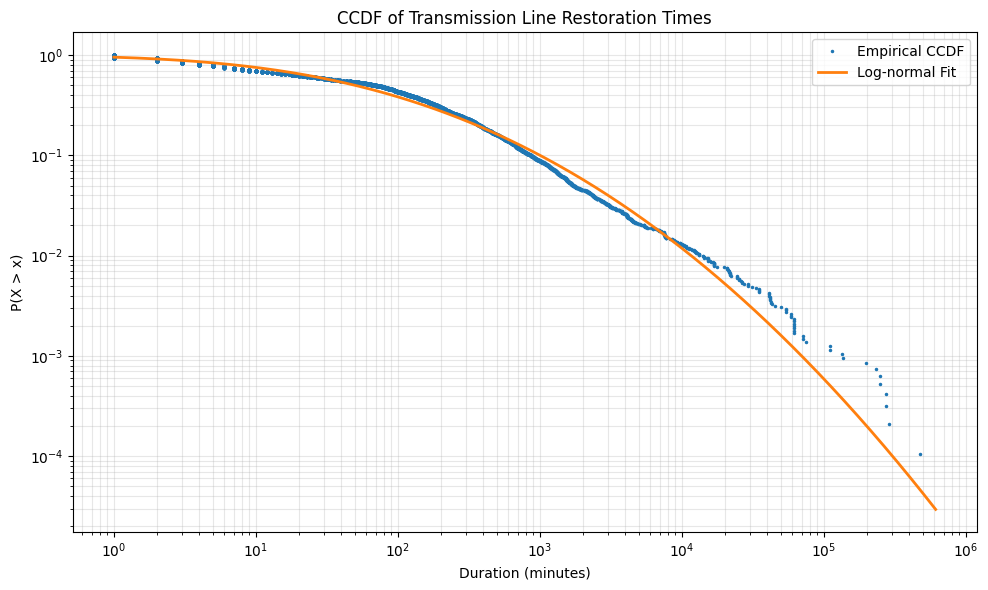

In [9]:
from scipy import stats as sp_stats

x = np.logspace(np.log10(duration_sorted.min()), np.log10(duration_sorted.max()), 1000)
ccdf_lognorm = 1 - sp_stats.lognorm.cdf(x, s=sigma, scale=np.exp(mu))

plt.figure(figsize=(10, 6))
plt.loglog(duration_sorted, ccdf, marker=".", linestyle="none", markersize=3, label="Empirical CCDF")
plt.loglog(x, ccdf_lognorm, linewidth=2, label="Log-normal Fit")
plt.xlabel("Duration (minutes)")
plt.ylabel("P(X > x)")
plt.title("CCDF of Transmission Line Restoration Times")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Log-normal 擬合有效範圍

## 5.1 Binary search + KS test

In [10]:
from scipy import stats

def ks_test_lognorm(data, cutoff):
    subset = data[data <= cutoff]
    if len(subset) < 30:
        return 0
    mu = np.log(subset).mean()
    sigma = np.log(subset).std()
    _, p_value = stats.kstest(subset, "lognorm", args=(sigma, 0, np.exp(mu)))
    return p_value

# log 空間 binary search
low = np.log(duration_sorted.min())
high = np.log(duration_sorted.max())

while high - low > 1e-3:
    mid = (low + high) / 2
    p = ks_test_lognorm(duration_sorted, np.exp(mid))
    if p > 0.10:
        low = mid
    else:
        high = mid

x_cutoff = np.exp(low)
print(f"截斷點 x_cutoff = {x_cutoff:.2f} 分鐘")
print(f"截斷點 x_cutoff = {x_cutoff/60:.2f} 小時")
print(f"截斷點 x_cutoff = {x_cutoff/1440:.2f} 天")

截斷點 x_cutoff = 1.00 分鐘
截斷點 x_cutoff = 0.02 小時
截斷點 x_cutoff = 0.00 天


In [11]:
# 抓幾個特定 cutoff 的 p 值來觀察
cutoffs = [10, 50, 100, 500, 1000, 2000, 5000, 10000, 50000]

for cutoff in cutoffs:
    subset = duration_sorted[duration_sorted <= cutoff]
    if len(subset) >= 30:
        mu_sub = np.log(subset).mean()
        sigma_sub = np.log(subset).std()
        _, p = stats.kstest(subset, "lognorm", args=(sigma_sub, 0, np.exp(mu_sub)))
        print(f"cutoff : {cutoff:8.0f} 分鐘, n={len(subset):5d}, p={p:.8f}")

cutoff :       10 分鐘, n= 2975, p=0.00000000
cutoff :       50 分鐘, n= 4383, p=0.00000000
cutoff :      100 分鐘, n= 5416, p=0.00000000
cutoff :      500 分鐘, n= 7991, p=0.00000000
cutoff :     1000 分鐘, n= 8675, p=0.00000000
cutoff :     2000 分鐘, n= 9082, p=0.00000000
cutoff :     5000 分鐘, n= 9313, p=0.00000000
cutoff :    10000 分鐘, n= 9388, p=0.00000000
cutoff :    50000 分鐘, n= 9481, p=0.00000000


## 5.2 說明與討論

KS Test（Kolmogorov-Smirnov Test）

* 原理

    KS test 計算實際 CCDF 和理論 CCDF 之間的最大差距（D 統計量）：
    >
    >    D = max|F_empirical(x) - F_theoretical(x)|
    >
    >    D 越小代表實際資料與理論分布越接近。

* p-value 計算

    1. 算出 D 統計量
    2. 將 D 標準化：D* = D × (√n + 0.12 + 0.11/√n)
    3. 將 D* 帶入 KS 分布的累積函數，得到 p-value

p-value 的直觀意思為：在 KS 分佈中觀測到這麼大或更大的 D 值的機率。

- p > 0.10 → 無法拒絕「資料符合該分布」的假設
- p ≤ 0.10 → 拒絕，資料不符合該分布

> 為何不適用於本題目 : 這個測試怎麼可能適合重尾，方法將最大誤差放大(跟 n 成正比)之後去觀察 KS 分佈超越該誤差的機率，但對於重尾情況來說，等於缺資料的地方不準確，準確的地方資料多，資料多還會去放大缺資料的誤差

# 6. 相對誤差檢核

* 原理

    >對每個資料點 x，計算實際 CCDF 與 log-normal 理論 CCDF 之間的相對誤差：
    >
    >   Relative Error = |F_empirical(x) - F_theoretical(x)| / F_empirical(x) => |預測值 - 實際值| / 實際值

* 相較於 KS test 只取最大差距，相對誤差法考慮每個點的誤差大小，能更全面反映整體的擬合品質，且不受樣本數影響。

* 誤差判斷標準 : 一般而言，相對誤差的判斷標準如下
    >
    > 誤差 < 5%：擬合非常好
    >
    > 誤差 5% ~ 10%：擬合良好，可接受
    >
    > 誤差 10% ~ 20%：擬合尚可，需注意偏離區間
    >
    > 誤差 > 20%：擬合較差，分布假設可能不適用

* 本資料的結果：

    - 中位數相對誤差 6.56%：整體擬合良好
    - 90th percentile 13.12%：90% 的資料點誤差在 13% 以內
    - 最大相對誤差 68.10%：尾部少數極端點偏離較大
    - 90th percentile = 0.1312：90% 的資料點，其相對誤差在 13.12% 以內
    - 95th percentile = 0.2341：95% 的資料點，其相對誤差在 23.41% 以內

因此 log-normal 在主體範圍內擬合良好，誤差主要集中在尾部極端值，為重尾分布的典型特徵。

In [12]:
# 計算每個點的相對誤差
x = duration_sorted
ccdf_empirical = 1 - np.arange(1, len(x) + 1) / len(x)
ccdf_lognorm = 1 - stats.lognorm.cdf(x, s=sigma, scale=np.exp(mu))

# 先過濾掉 ccdf_empirical = 0 的點，再計算相對誤差
mask = ccdf_empirical > 0
x_valid = x[mask]
ccdf_empirical_valid = ccdf_empirical[mask]
ccdf_lognorm_valid = ccdf_lognorm[mask]

relative_error = np.abs(ccdf_empirical_valid - ccdf_lognorm_valid) / ccdf_empirical_valid

print(f"平均相對誤差: {relative_error.mean():.4f}")
print(f"中位數相對誤差: {np.median(relative_error):.4f}")
print(f"最大相對誤差: {relative_error.max():.4f}")
print(f"90th percentile: {np.percentile(relative_error, 90):.4f}")
print(f"95th percentile: {np.percentile(relative_error, 95):.4f}")

平均相對誤差: 0.0773
中位數相對誤差: 0.0667
最大相對誤差: 0.7857
90th percentile: 0.1231
95th percentile: 0.2105


# 7. 總結與策略

* 總結 : 

我認為主要問題出現在過於極端的修復時間上，完全同意極端事件的出現，但有部分修復時間數據超越 3 個月甚至達 2 年(這種修復時間，是會讓總統下台的那種，即便是以 921 全台灣電廠、輸電、配電全線受損的情況也才停 21 天)，就以常識而言怎麼可能會有這種情況，推測是由於該線路損壞後，採用其他線路供電，這條線路就慢慢修了，故將這些數據納入災害後復原分析並不具有意義，故建議設定修復時間上限值，以鐵塔倒塌修復時間 10 天作為上限值。

* 策略 : 
當給予模型機率事件時，超過 10 天的機率事件，維修時長以 10 天計算